# Entregável 5 — Estratégia de Segmentação de Sinais ECG

**Disciplina:** Aquisição e Processamento de Biossinais  
**Equipe:** José Ferreira Lessa & Matheus Rocha Gomes da Silva  
**Orientador:** Prof. Dr. Victor Hugo C. de Albuquerque  
**Dataset:** PTB-XL — A Large Publicly Available Electrocardiography Dataset (PhysioNet)  
**Referência:** Wagner et al. (2020). PTB-XL, a large publicly available electrocardiography dataset. *Scientific Data*, 7(1), 154.  
**Data:** Março e Abril de 2026

---

## Introdução e Metodologia
Nesta etapa, estruturamos a forma como os dados de ECG (10 segundos) serão segmentados para a extração de atributos no Entregável 6. 

Diferentes de aplicações de *Deep Learning* que costumam utilizar janelas curtas com sobreposição para aumentar o volume de dados (N), para a extração de atributos clássicos (SVM, RF, etc.), essa prática pode introduzir correlação artificial e redudância excessiva (*label inflation*). 

**Decisão de Projeto:** 
Adotamos os **10 segundos como instância principal (Opção A)** para preservar a unidade clínica original do dataset. Paralelamente, implementamos a **Segmentação por Batimento (Opção C)** apenas como uma etapa intermediária para calcular atributos de morfologia e variabilidade, que serão agregados e devolvidos ao nível do registro de 10 segundos.

## 1. Configuração do Ambiente

In [1]:
import os
import ast
import gc
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal as signal
from tqdm.notebook import tqdm
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Estética
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

## 2. Parâmetros e Diretórios

In [2]:
# Parâmetros
FS = 100
LEAD_NAMES = ['I', 'II', 'III', 'aVL', 'aVR', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

# Diretórios
DIR_OUT_D4 = '../../entregavel-4/outputs/'
DIR_OUT_D5 = '../outputs/'
FIGS_DIR = '../figuras/'

os.makedirs(DIR_OUT_D5, exist_ok=True)
os.makedirs(FIGS_DIR, exist_ok=True)

## 3. Leitura do Dataset Processado

In [3]:
print("Carregando sinais limpos e metadados...")
npy_path = os.path.join(DIR_OUT_D4, 'sinais_limpos_100hz.npy')
csv_path = os.path.join(DIR_OUT_D4, 'ptbxl_filtrados_sqi_indices_ordenados.csv')

sinais = np.load(npy_path)
df = pd.read_csv(csv_path, index_col='ecg_id')
df['diagnostic_superclass'] = df['diagnostic_superclass'].apply(ast.literal_eval)

print(f"Dataset carregado: {len(sinais)} registros de 10s (1000 amostras cada).")

Carregando sinais limpos e metadados...
Dataset carregado: 21735 registros de 10s (1000 amostras cada).


---
## Seção 1 — Estruturação do Dataset de Nível Superior (10 segundos)

Conforme decidido, cada registro de 10 segundos constitui uma instância única. O objetivo nesta seção é apenas propagar os metadados e validar a ordem dos registros antes da extração de features globais.

In [4]:
# Propagação de identificadores e superclasses diagnósticas
df_instancias_10s = df[['patient_id', 'strat_fold', 'sqi_category', 'sqi_score', 'diagnostic_superclass']].copy()

# Validação final do balanceamento
resumo_folds = df_instancias_10s['strat_fold'].value_counts().sort_index()
display(Markdown("**Distribuição de Registros por Fold:**"))
display(resumo_folds)

df_instancias_10s.to_csv(os.path.join(DIR_OUT_D5, 'registros_ids.csv'))

**Distribuição de Registros por Fold:**

strat_fold
1     2171
2     2175
3     2185
4     2172
5     2168
6     2165
7     2169
8     2167
9     2178
10    2185
Name: count, dtype: int64

---
## Seção 2 — Segmentação por Batimento (Análise Morfológica)

### 2.1 Algoritmo de Detector de Picos R (Pan-Tompkins Nativo)
Implementamos um detector baseado na lógica de Pan-Tompkins para identificar o momento exato de cada sístole ventricular (onda R).
1. **Filtro Digital**: Passa-banda entre 5-15 Hz.
2. **Derivada e Quadratura**: Enfatiza a inclinação característica do QRS.
3. **Integração**: Suaviza picos múltiplos para detecção de energia volumétrica.
4. **Localização**: Identifica os picos e aplica período refratário de 200ms.

In [5]:
def detector_pan_tompkins(sinal_v, fs=100):
    """Implementação nativa do detector Pan-Tompkins para detecção de picos R."""
    # 1. Bandpass 5-15 Hz
    nyq = 0.5 * fs
    b, a = signal.butter(2, [5/nyq, 15/nyq], btype='bandpass')
    f = signal.filtfilt(b, a, sinal_v)
    
    # 2. Derivada e Quadratura
    d = np.diff(f)
    s = d**2
    
    # 3. Moving Average (150ms)
    ma = np.convolve(s, np.ones(int(0.15 * fs))/int(0.15 * fs), mode='same')
    
    # 4. Busca de picos
    picos, _ = signal.find_peaks(ma, distance=int(0.2 * fs), prominence=np.max(ma)*0.05)
    return picos

def extrair_janelas_beat(sig_12l, picos, fs=100):
    """Extrai janelas de 600ms (200ms pre, 400ms post) centradas no pico R."""
    bt, meta = [], []
    pre, post = int(0.2 * fs), int(0.4 * fs)
    
    for i, r_idx in enumerate(picos):
        if r_idx > pre and r_idx < (1000 - post):
            bt.append(sig_12l[r_idx - pre : r_idx + post, :])
            rr = (picos[i+1] - r_idx) * (1000/fs) if i < (len(picos)-1) else np.nan
            meta.append({'r_peak_idx': r_idx, 'rr_interval_ms': rr})
            
    return np.array(bt, dtype=np.float32), meta

### 2.2 Processamento do Dataset Completo

In [6]:
lista_bt_final = []
lista_meta_bt = []

for i, eid in enumerate(tqdm(df.index, desc='Extraindo batimentos')):
    curr_sig = sinais[i]
    pks = detector_pan_tompkins(curr_sig[:, 1], FS) # Lead II como referência
    janelas, meta_janelas = extrair_janelas_beat(curr_sig, pks, FS)
    
    if len(janelas) > 0:
        lista_bt_final.append(janelas)
        for m in meta_janelas:
            m.update({'ecg_id': eid, 'patient_id': df.loc[eid, 'patient_id'], 
                      'strat_fold': df.loc[eid, 'strat_fold'],
                      'diagnostic_superclass': df.loc[eid, 'diagnostic_superclass']})
            lista_meta_bt.append(m)

# OTIMIZAÇÃO DE MEMÓRIA: Liberar os sinais de 10s após a extração
print("Liberando memória (sinais de 10s)...")
del sinais
gc.collect()

# Concatenação eficiente
matriz_bt = np.concatenate(lista_bt_final, axis=0)
df_bt_ids = pd.DataFrame(lista_meta_bt)
del lista_bt_final
gc.collect()

print(f"Total de batimentos extraídos: {len(matriz_bt)} ({matriz_bt.shape})")

Extraindo batimentos:   0%|          | 0/21735 [00:00<?, ?it/s]

Liberando memória (sinais de 10s)...
Total de batimentos extraídos: 269004 ((269004, 60, 12))


---
## Seção 3 — Validação da Segmentação e Estabilidade

### 3.1 Métricas de Ritmo e Frequência cardíaca (FC)
Validamos se os batimentos detectados condizem com as superclasses esperadas. Um detector preciso deve mostrar maior variabilidade (SDNN) em casos de Arritmia (AFIB).

In [7]:
# FC e SDNN por registro
df_rr_calc = df_bt_ids.dropna(subset=['rr_interval_ms'])
stats_ritmo = df_rr_calc.groupby('ecg_id')['rr_interval_ms'].agg(['mean', 'std']).rename(columns={'mean': 'mean_RR', 'std': 'sd_RR'})
stats_ritmo['fc_bpm'] = 60000 / stats_ritmo['mean_RR']

# Cruzamento com labels (extração segura do primeiro label ou 'NONE')
def get_safe_label(x):
    if isinstance(x, list) and len(x) > 0:
        return x[0]
    return 'NONE'

df_val = stats_ritmo.join(df['diagnostic_superclass'].apply(get_safe_label), how='inner')

display(Markdown("**Estatísticas de Ritmo por Superclasse (Mediana):**"))
display(df_val.groupby('diagnostic_superclass')[['fc_bpm', 'sd_RR']].median().round(1))

**Estatísticas de Ritmo por Superclasse (Mediana):**

,fc_bpm,sd_RR
diagnostic_superclass,,
CD,77.4,31.6
HYP,75.4,25.6
MI,77.0,36.8
NONE,76.4,34.8
NORM,71.4,30.2
STTC,76.4,27.1


### 3.2 Estabilidade do Sinal de 10 Sedungos
Calculamos o Zero Crossing Rate (ZCR) e a Variância para garantir que as janelas não contenham sinais mortos ou artefatos de amplitude irreal.

In [8]:
# Nota: Como 'sinais' foi deletado, recarregamos de forma dinâmica via mmap para validação estatística
sinais_mmap = np.load(npy_path, mmap_mode='r')

# Cálculo de estabilidade na Lead II para uma amostra de 20% do dataset
sample_idx = np.random.choice(len(df), size=int(len(df)*0.2), replace=False)
zcr, var_s = [], []

for idx in sample_idx:
    s_test = sinais_mmap[idx, :, 1]
    zcr.append(np.sum(np.diff(np.sign(s_test)) != 0) / 1000)
    var_s.append(np.var(s_test))

df_stab = pd.DataFrame({'zcr': zcr, 'var': var_s})
display(Markdown(f"**Validação de Estabilidade (Amostra 20%):** ZCR Médio: {np.mean(zcr):.4f} | Variância Média: {np.mean(var_s):.4f}"))
del sinais_mmap, zcr, var_s

**Validação de Estabilidade (Amostra 20%):** ZCR Médio: 0.0930 | Variância Média: 0.0174

---
## Seção 4 — Visualizações Adicionais e Alinhamento

### 4.1 Validação de Alinhamento de Batimentos (Poincaré & Sobreposição)
Verificamos a precisão do detector de Pan-Tompkins através da sobreposição dos batimentos extraídos de um registro de controle.

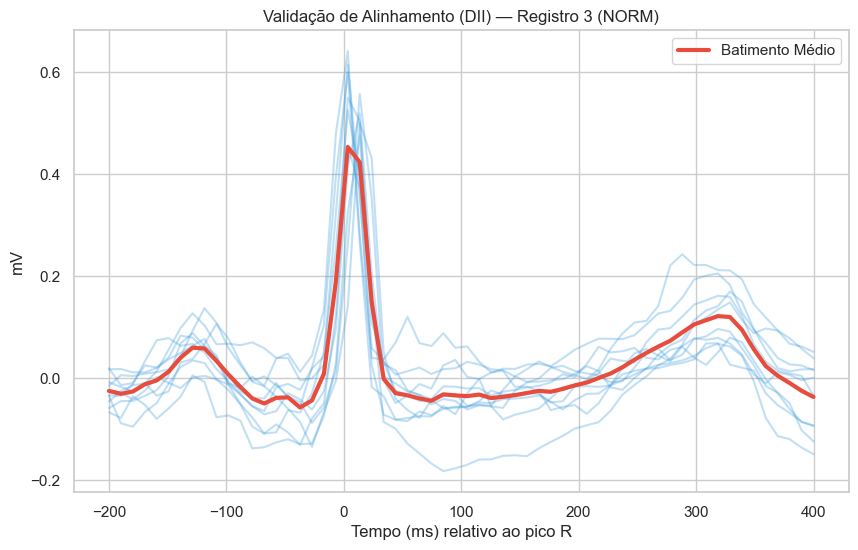

In [9]:
# Busca por um registro NORM com boa detecção
eid_norm = df_val[df_val['diagnostic_superclass'] == 'NORM'].index[2]
indices_norm_beats = df_bt_ids[df_bt_ids['ecg_id'] == eid_norm].index

plt.figure(figsize=(10, 6))
t = np.linspace(-200, 400, 60)
for idx in indices_norm_beats:
    plt.plot(t, matriz_bt[idx, :, 1], color='#3498db', alpha=0.3)

plt.plot(t, np.mean(matriz_bt[indices_norm_beats, :, 1], axis=0), color='#e74c3c', lw=3, label='Batimento Médio')
plt.title(f'Validação de Alinhamento (DII) — Registro {eid_norm} (NORM)')
plt.xlabel('Tempo (ms) relativo ao pico R')
plt.ylabel('mV')
plt.legend()
plt.savefig(os.path.join(FIGS_DIR, 'sobreposicao_beats.png'), dpi=150)
plt.show()

### 4.2 Painel de Comparação por Superclasse (15 Exemplos)
Abaixo, apresentamos uma visão panorâmica de 3 registros para cada uma das 5 superclasses principais, permitindo uma inspeção visual rápida da qualidade dos sinais que seguem para a extração de features.

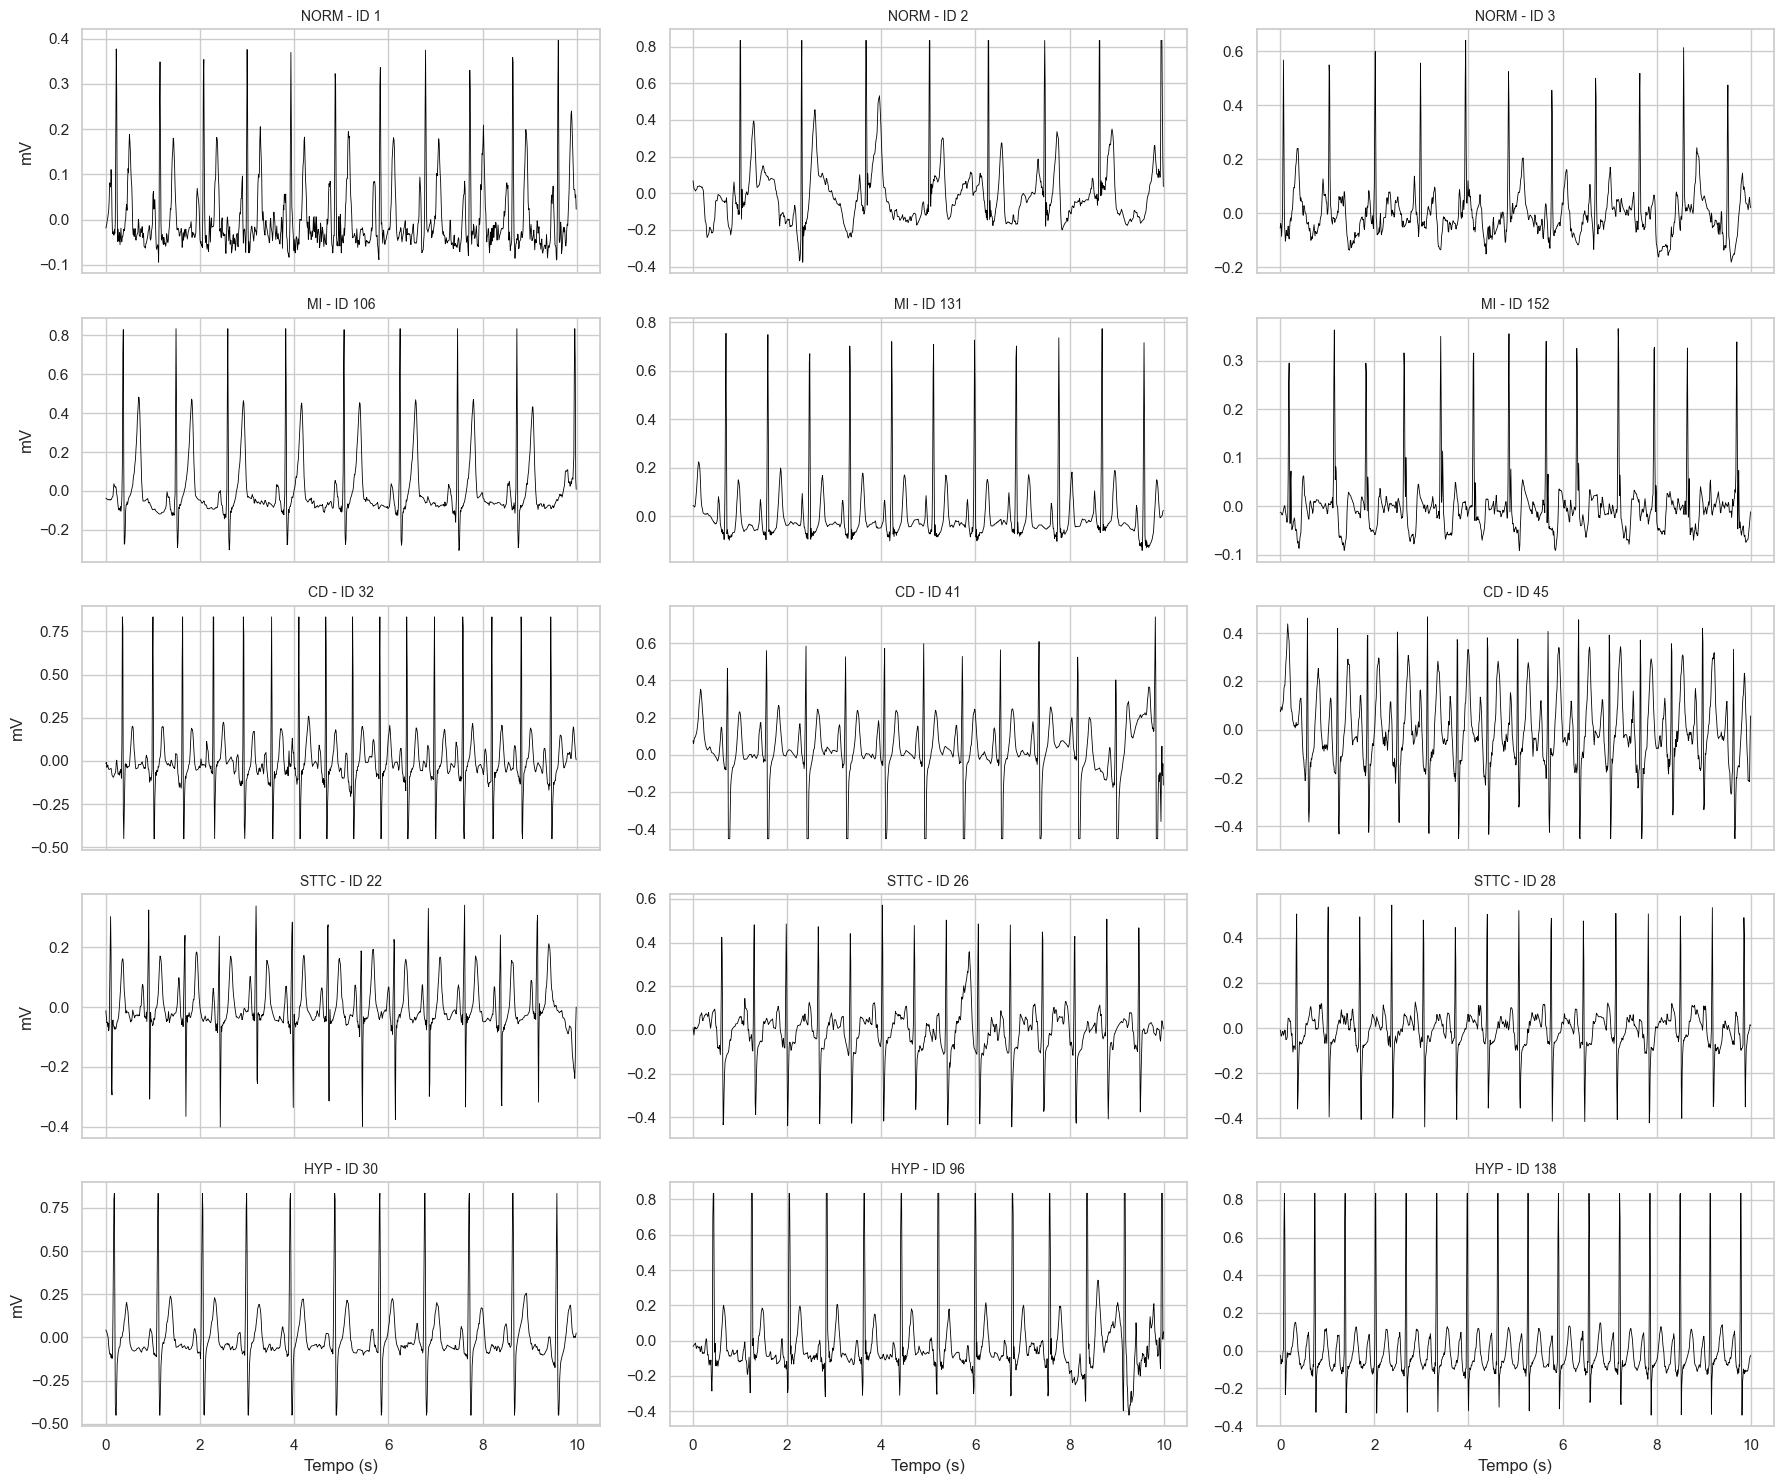

In [10]:
sinais_tmp = np.load(npy_path, mmap_mode='r')
classes = ['NORM', 'MI', 'CD', 'STTC', 'HYP']
fig, axes = plt.subplots(len(classes), 3, figsize=(18, 15), sharex=True)

for i, c in enumerate(classes):
    # Seleção segura: pega até 3 exemplos, ou os que estiverem disponíveis
    c_examples = df_val[df_val['diagnostic_superclass'] == c].index
    n_show = min(len(c_examples), 3)
    
    for j in range(3):
        if j < n_show:
            eid = c_examples[j]
            loc = df.index.get_loc(eid)
            axes[i, j].plot(np.arange(1000)/100, sinais_tmp[loc, :, 1], color='black', lw=0.6)
            axes[i, j].set_title(f'{c} - ID {eid}', fontsize=10)
        else:
            axes[i, j].text(0.5, 0.5, 'N/A', ha='center', va='center')
            axes[i, j].set_axis_off()
        
        if j == 0: axes[i, j].set_ylabel('mV')
        if i == len(classes)-1: axes[i, j].set_xlabel('Tempo (s)')

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'painel_15_exemplos.png'), dpi=200)
plt.show()
del sinais_tmp

---
## Seção 5 — Exportação de Artefatos e Síntese Final

Concluímos a segmentação garantindo dois níveis de dados para a próxima etapa (Extração de Features):
1. **Nível Registro (10s):** Matriz original preservada para features globais.
2. **Nível Batimento (600ms):** Segmentos alinhados para features de morfologia.

**Arquivos Salvos em:** `outputs/`

In [11]:
# Salvamento final
np.save(os.path.join(DIR_OUT_D5, 'batimentos_segmentados.npy'), matriz_bt)
df_bt_ids.to_csv(os.path.join(DIR_OUT_D5, 'batimentos_ids.csv'), index=False)

summary = f"""
- **Mapeamento 10s**: `registros_ids.csv` ({len(df_instancias_10s)} instâncias)
- **Matriz Batimentos**: `batimentos_segmentados.npy` ({matriz_bt.shape})
- **Metadados Batimentos**: `batimentos_ids.csv`
"""
display(Markdown(summary))


- **Mapeamento 10s**: `registros_ids.csv` (21735 instâncias)
- **Matriz Batimentos**: `batimentos_segmentados.npy` ((269004, 60, 12))
- **Metadados Batimentos**: `batimentos_ids.csv`
